In [3]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# pip install pandas numpy joblib scikit-learn matplotlib seaborn

  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Usi


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
df = pd.read_csv("diabetes.csv")
print("✅ Loaded diabetes.csv successfully!")
print(f"   Shape: {df.shape}")
print(df.head())
 
X = df.drop("Outcome", axis=1)   # Features
y = df["Outcome"] 

✅ Loaded diabetes.csv successfully!
   Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [6]:
print("\n--- Dataset Info ---")
print(df.info())
 
print("\n--- Class Distribution ---")
print(y.value_counts())
print("   0 = Not Diabetic | 1 = Diabetic")


--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

--- Class Distribution ---
Outcome
0    500
1    268
Name: count, dtype: int64
   0 = Not Diabetic | 1 = Diabetic


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
 
print(f"\n✅ Train size: {X_train_scaled.shape}, Test size: {X_test_scaled.shape}")


✅ Train size: (614, 8), Test size: (154, 8)


In [10]:
K = 5  # Select top 5 features (out of 8)
 
selector = SelectKBest(score_func=f_classif, k=K)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected  = selector.transform(X_test_scaled)

feature_names  = X.columns.tolist()
selected_mask  = selector.get_support()
selected_feats = [feature_names[i] for i, m in enumerate(selected_mask) if m]
 
print(f"\n--- Feature Selection (Top {K}) ---")
print(f"   Selected Features: {selected_feats}")


--- Feature Selection (Top 5) ---
   Selected Features: ['Pregnancies', 'Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age']


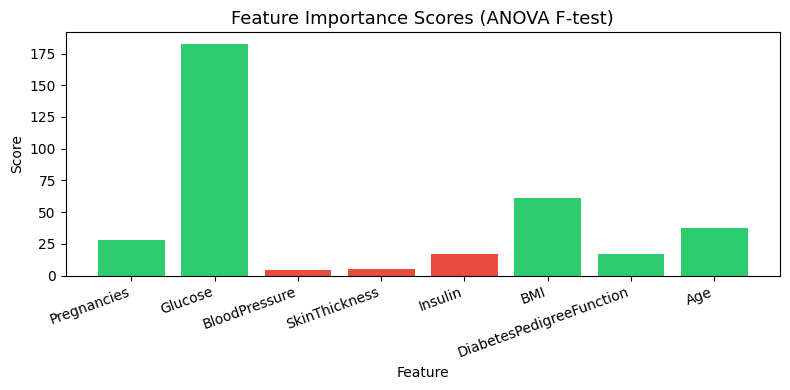

   📊 Saved: feature_scores.png


In [11]:
scores = selector.scores_
plt.figure(figsize=(8, 4))
colors = ["#2ecc71" if m else "#e74c3c" for m in selected_mask]
plt.bar(feature_names, scores, color=colors)
plt.title("Feature Importance Scores (ANOVA F-test)", fontsize=13)
plt.xlabel("Feature")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("feature_scores.png", dpi=120)
plt.show()
print("   📊 Saved: feature_scores.png")

In [12]:
# --- Model 1: KNN (K-Nearest Neighbors) ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_selected, y_train)
knn_preds = knn.predict(X_test_selected)
 
# --- Model 2: SVM (Support Vector Machine) ---
svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm.fit(X_train_selected, y_train)
svm_preds = svm.predict(X_test_selected)
 
print("\n✅ Both models trained!")


✅ Both models trained!


In [13]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Accuracy : {acc * 100:.2f}%")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, target_names=["No Diabetes", "Diabetes"]))
    return acc
 
knn_acc = evaluate_model("KNN (K=5)", y_test, knn_preds)
svm_acc = evaluate_model("SVM (RBF Kernel)", y_test, svm_preds)


  KNN (K=5)
  Accuracy : 74.03%

  Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.78      0.83      0.81       100
    Diabetes       0.65      0.57      0.61        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.71       154
weighted avg       0.73      0.74      0.74       154


  SVM (RBF Kernel)
  Accuracy : 75.32%

  Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.78      0.87      0.82       100
    Diabetes       0.69      0.54      0.60        54

    accuracy                           0.75       154
   macro avg       0.73      0.70      0.71       154
weighted avg       0.75      0.75      0.74       154



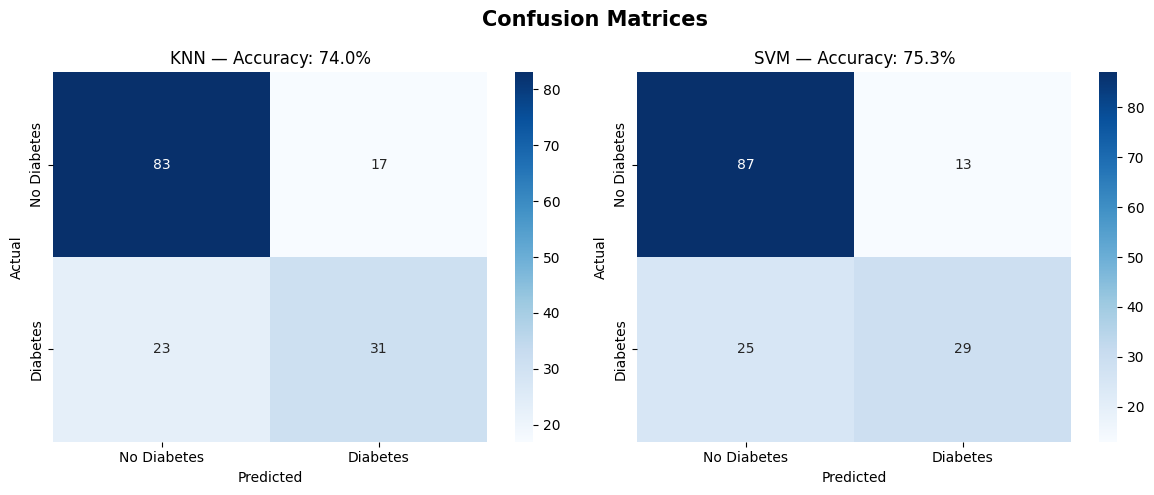

📊 Saved: confusion_matrices.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrices", fontsize=15, fontweight="bold")
 
for ax, name, preds in zip(axes,
                            ["KNN", "SVM"],
                            [knn_preds, svm_preds]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Diabetes", "Diabetes"],
                yticklabels=["No Diabetes", "Diabetes"])
    ax.set_title(f"{name} — Accuracy: {accuracy_score(y_test, preds)*100:.1f}%")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
 
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120)
plt.show()
print("📊 Saved: confusion_matrices.png")

In [15]:
print("\n--- Model Comparison ---")
print(f"   KNN Accuracy : {knn_acc * 100:.2f}%")
print(f"   SVM Accuracy : {svm_acc * 100:.2f}%")
 
if svm_acc > knn_acc:
    best_model      = svm
    best_model_name = "SVM"
    best_acc        = svm_acc
elif knn_acc > svm_acc:
    best_model      = knn
    best_model_name = "KNN"
    best_acc        = knn_acc
else:
    best_model      = svm   # default to SVM on tie
    best_model_name = "SVM"
    best_acc        = svm_acc
 
print(f"\n   🏆 Best Model: {best_model_name} ({best_acc * 100:.2f}%)")
 
# Save the best model + scaler + selector (all needed for future predictions)
joblib.dump(best_model,  "best_model.pkl")
joblib.dump(scaler,      "scaler.pkl")
joblib.dump(selector,    "selector.pkl")
 
print(f"\n✅ Saved:")
print(f"   best_model.pkl  → {best_model_name} model")
print(f"   scaler.pkl      → StandardScaler (for preprocessing)")
print(f"   selector.pkl    → Feature selector (top {K} features)")


--- Model Comparison ---
   KNN Accuracy : 74.03%
   SVM Accuracy : 75.32%

   🏆 Best Model: SVM (75.32%)

✅ Saved:
   best_model.pkl  → SVM model
   scaler.pkl      → StandardScaler (for preprocessing)
   selector.pkl    → Feature selector (top 5 features)
